 Calcule la TDF de una imagen, obtenga magnitud y fase.
Genere una imagen reconstruida s´olo con la magnitud considerando fase cero
y genere otra imagen reconstruida usando s´olo fase de la imagen considerando
magnitud unitaria.
Visualice las im´agenes y saque conclusiones sobre el aporte de ambas componentes a la reconstrucci´on de la imagen.
2. Reproduzca el experimento de Openheim utilizando las im´agenes puente.jpg
y ferrari-c.png. Visualice y comente los resultados

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def graph_fft_3d(width, height, magnitude):
    x = np.arange(width)
    y = np.arange(height)
    X, Y = np.meshgrid(x, y)

    fig = go.Figure(
        data=[
            go.Surface(
                z=magnitude,
                x=X,
                y=Y
            )
        ]
    )

    fig.update_layout(
        title="Magnitud de la FFT (3D)",
        scene=dict(
            xaxis_title="Frecuencia X",
            yaxis_title="Frecuencia Y",
            zaxis_title="Magnitud"
        ),
        width=800,
        height=700
    )

    fig.show()
    

# Experimento de oppenheimer!!!
Ver la importancia de la magnitud y la fase en la reconstrucción de la imagen.

## analisis puente

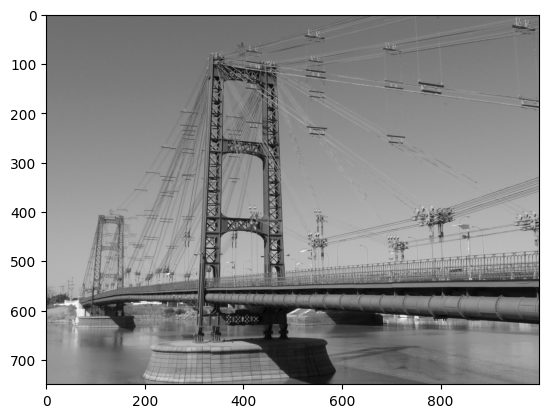

In [2]:
# cargamos la imagen

img = cv2.imread("../Imagenes_cursado/puente.jpg",cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.show()

las tdf devuelve numeros de la forma a + jb. la fase se calcula como arctan(b/a)

para la reconstruccion

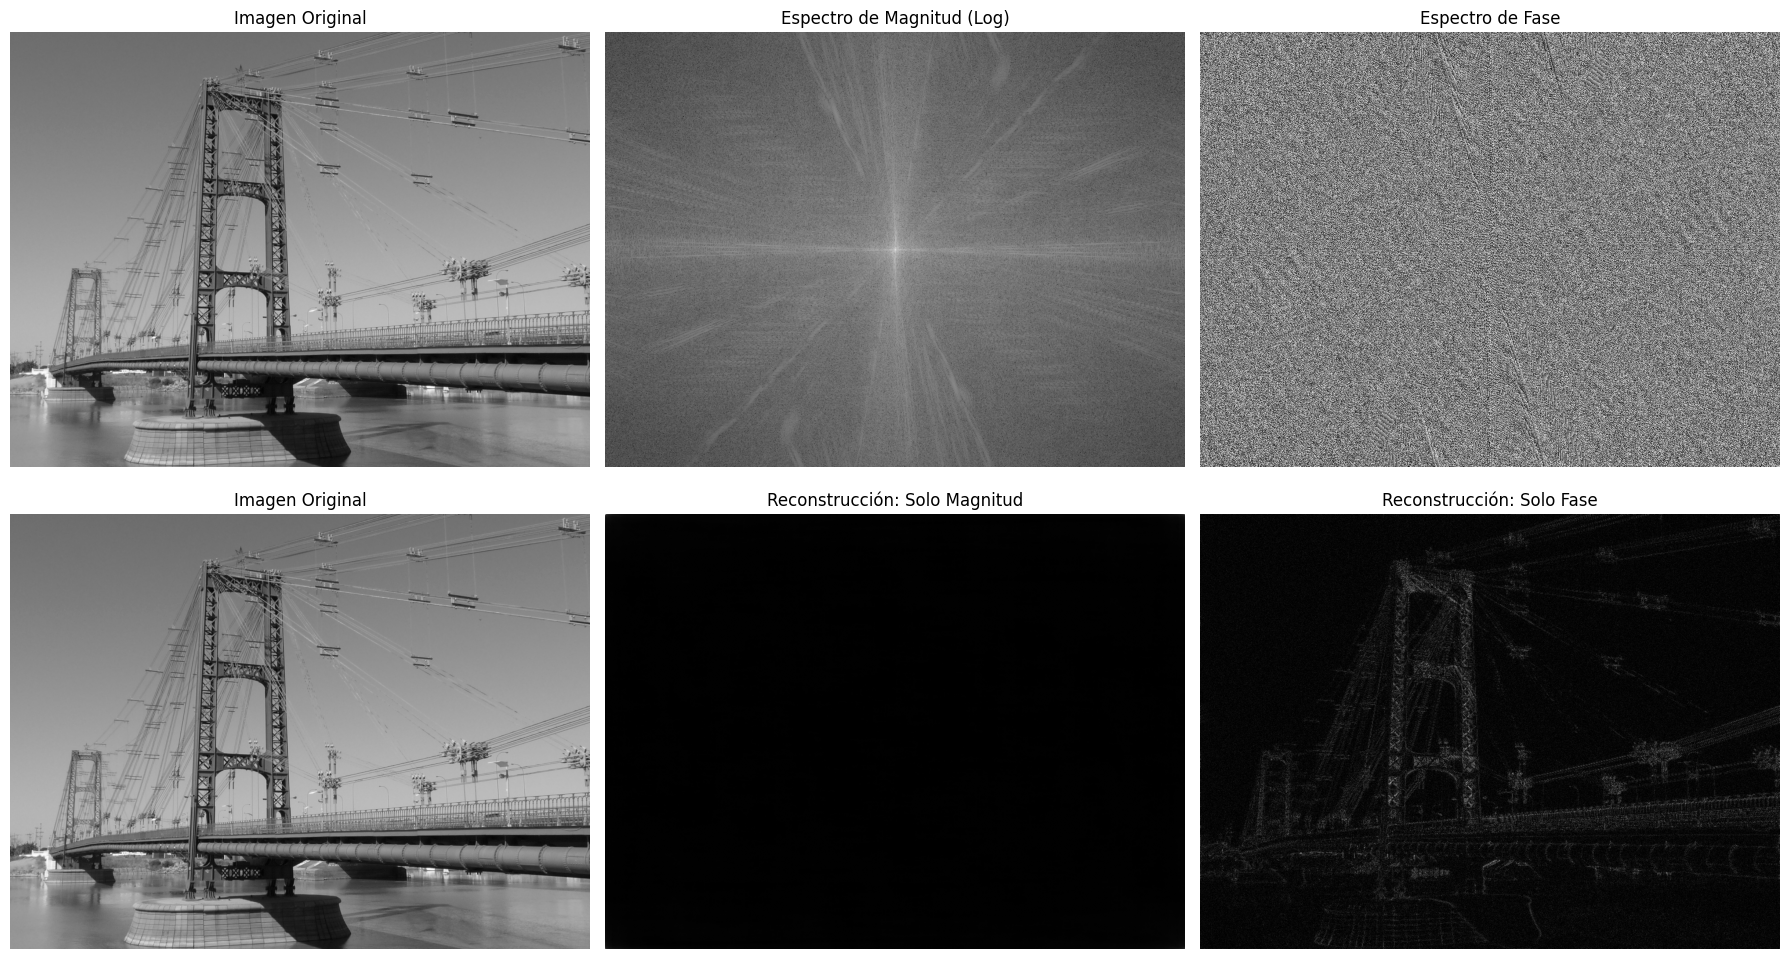

In [3]:
# hacemos la transformada y vemos que onda

fft = np.fft.fft2(img) #son numeros complejos de la forma a + jb

magnitude = np.abs(fft)
fase = np.angle(fft) #me da angulos reales, pero lo necesito pasarlo a complejo



#reconstruccion utilizando la magnitud

img_only_mod = np.fft.ifft2(magnitude)
img_only_fase = np.fft.ifft2(np.exp(1j*fase))


plt.figure(figsize=(18, 10))

# Imagen Original
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

# Magnitud (en escala logarítmica para ver algo)
plt.subplot(2, 3, 2)
plt.imshow(np.log(1 + np.fft.fftshift(magnitude)), cmap='gray')
plt.title('Espectro de Magnitud (Log)')
plt.axis('off')

# Fase
plt.subplot(2, 3, 3)
plt.imshow(np.fft.fftshift(fase), cmap='gray')
plt.title('Espectro de Fase')
plt.axis('off')

# Imagen Original
plt.subplot(2, 3, 4)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')


# Reconstrucción solo con magnitud
# Usamos np.abs porque el resultado de ifft2 es complejo (aunque la parte imaginaria sea despreciable)
plt.subplot(2, 3, 5)
plt.imshow(np.abs(img_only_mod), cmap='gray')
plt.title('Reconstrucción: Solo Magnitud')
plt.axis('off')

# Reconstrucción solo con fase
plt.subplot(2, 3, 6)
plt.imshow(np.abs(img_only_fase), cmap='gray')
plt.title('Reconstrucción: Solo Fase')
plt.axis('off')

plt.tight_layout()
plt.savefig('reconstruccion_fourier.png')
plt.show()

Vemos que se cumple un poco lo que se esperaba:
- En la reconstruccion utilizando solo la fase se notan bastante los bordes
- La reconstrucción de la imagen original deja mucho que desear

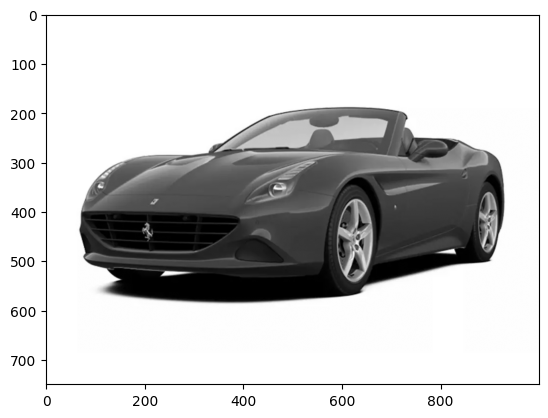

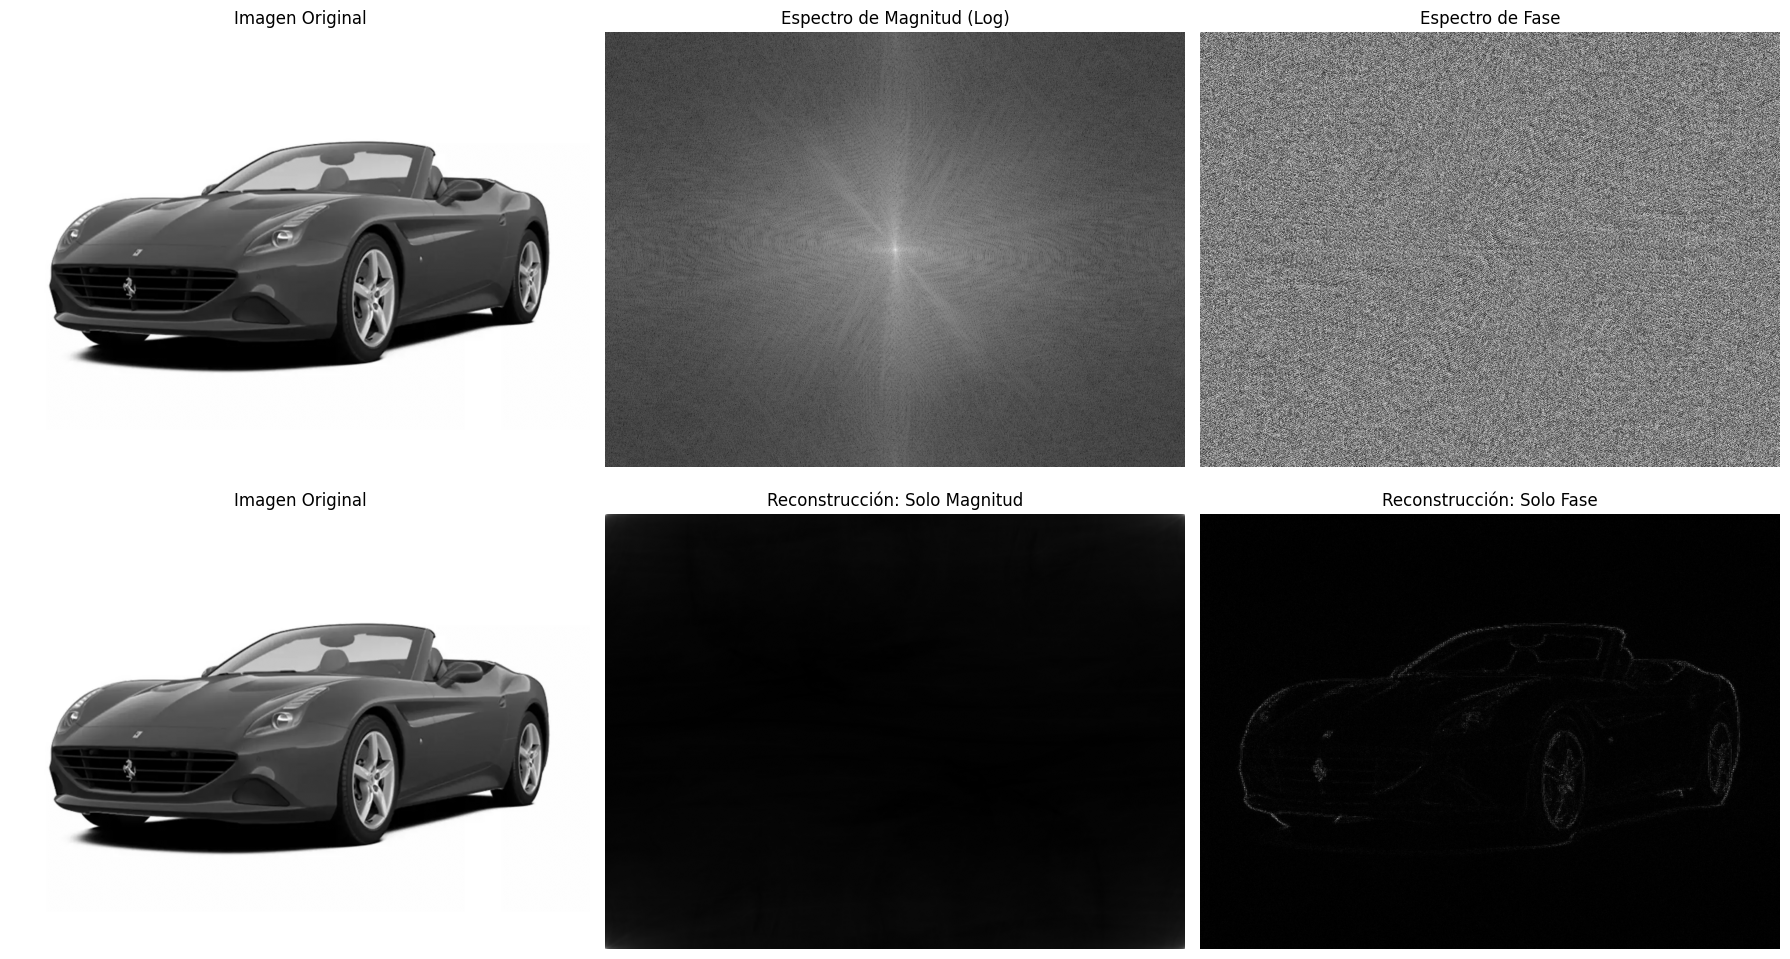

In [4]:
# reproducimos el experimento con ferrari-c.png



img = cv2.imread("../Imagenes_cursado/ferrari-c.png",cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.show()


# hacemos la transformada y vemos que onda

fft = np.fft.fft2(img) #son numeros complejos de la forma a + jb

magnitude = np.abs(fft)
fase = np.angle(fft) #me da angulos reales, pero lo necesito pasarlo a complejo



#reconstruccion utilizando la magnitud

img_only_mod = np.fft.ifft2(magnitude)
img_only_fase = np.fft.ifft2(np.exp(1j*fase))


plt.figure(figsize=(18, 10))

# Imagen Original
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

# Magnitud (en escala logarítmica para ver algo)
plt.subplot(2, 3, 2)
plt.imshow(np.log(1 + np.fft.fftshift(magnitude)), cmap='gray')
plt.title('Espectro de Magnitud (Log)')
plt.axis('off')

# Fase
plt.subplot(2, 3, 3)
plt.imshow(np.fft.fftshift(fase), cmap='gray')
plt.title('Espectro de Fase')
plt.axis('off')

# Imagen Original
plt.subplot(2, 3, 4)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')


# Reconstrucción solo con magnitud
# Usamos np.abs porque el resultado de ifft2 es complejo (aunque la parte imaginaria sea despreciable)
plt.subplot(2, 3, 5)
plt.imshow(np.abs(img_only_mod), cmap='gray')
plt.title('Reconstrucción: Solo Magnitud')
plt.axis('off')

# Reconstrucción solo con fase
plt.subplot(2, 3, 6)
plt.imshow(np.abs(img_only_fase), cmap='gray')
plt.title('Reconstrucción: Solo Fase')
plt.axis('off')

plt.tight_layout()
plt.savefig('reconstruccion_fourier.png')
plt.show()